In [1]:
import pandas as pd 
from pandas import CategoricalDtype 
import numpy as np
import sqlite3
import plotnine as pm
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
apt_per_phase = pd.read_csv('/kaggle/input/datasets/micahluftig/from-sql-joins/avg_appt_per_moonphase.csv')
p_data = pd.read_csv('/kaggle/input/datasets/micahluftig/from-sql-joins/p_data.csv')
apt_data = pd.read_csv('/kaggle/input/datasets/micahluftig/from-sql-joins/apt_data.csv')
weather_y_apts_per_day = pd.read_csv('/kaggle/input/datasets/micahluftig/dasaxz/other_environmental_variables.csv')

In [3]:
def table_check(df, df_name) -> pd.DataFrame:
    '''
    Checks and prints the count of null (NaN) values for every column in a Pandas DataFrame.
    '''
    header()
    print(f'Beginning errorcheck for: {df_name} ***')
    print(f'\n--- Null Value Check ---')
    for column in df.columns: 
        null_count = df[column].isna().sum() 
        print(f'{column} nulls: {null_count}')
    print('\n')
    
    print(f'--- Integrity Check ---')
    if 'appointment_id' in df.columns:
        duplicate_count = df['appointment_id'].duplicated().sum()
        print(f'Total appointment_id duplicates: {duplicate_count}')
    else:
        print("WARNING: 'appointment_id' not found for duplication check.")
    print('\n')
    print(f'\n--- Data Type Audit (DF.dtypes) ---')
    print(df.dtypes)
    
    print(f'\n--- Numerical Sanity Check (DF.describe) ---')
    
    numeric_cols = df.select_dtypes(include = ['int64', 'float64', 'Int64', 'int32']).columns
    if not numeric_cols.empty:
        print(df[numeric_cols].describe())
    else:
        print('No standard numerical columns found for description.')

    print(f'\n--- Categorical Value Audit (Top 10 Counts) ---')
    object_cols = df.select_dtypes(include=['object']).columns

    for column in object_cols:
        print(f'\n{column.upper()}:')
        print(df[column].value_counts().nlargest(10))
    
    print('\n\n\n')
    
    return df

def normality_test(df, y_axis, x_axis):
    
    df_clean = df.dropna(subset=[y_axis, x_axis]).copy()
    
    transformations = {
        f'Regular ({y_axis})': df_clean[y_axis],
        f'Log (log({y_axis} + 0.001))': np.log(df_clean[y_axis] + 0.001),
        f'Sqrt (sqrt({y_axis}))': np.sqrt(df_clean[y_axis]),
        f'Log-Sqrt (log(sqrt({y_axis}) + 0.001))': np.log(np.sqrt(df_clean[y_axis]) + 0.001)
    }
    
    print('=' * 50)
    print(f'{y_axis} by {x_axis}\n\n')
    
    
    for label, y_values in transformations.items():
        
        df_clean['temp_y'] = y_values
        residuals = smf.ols(f'temp_y ~ {x_axis}', data=df_clean).fit().resid
        stat, p_val = stats.shapiro(residuals)
        
        
        print(f'{label}')
        print(f'Transformation: {label}')
        print(f'  W = {stat:.5f}, p-value = {p_val:.5e}\n')
        
    print('=' * 50)
    return df



def normality_plot(df, y_axis):
    epsilon = 0.001
    y_clean = df[y_axis].dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(8, 5))
    
    
    transformations = [
        ('regular', y_clean),
        ('sqrt', np.sqrt(y_clean)),
        ('log', np.log(y_clean + epsilon)),
        ('log(sqrt)', np.log(np.sqrt(y_clean) + epsilon))
    ]
    
   
    for (title, y_values), ax in zip(transformations, axes.flat):
        stats.probplot(y_values, plot=ax)
        ax.set_title(f'Normal Q-Q: {title}')
    plt.tight_layout()
    plt.show()
    
    return df

def kruskal_wallis(df, y_axis, x_axis):
    # 1. Gather the data groups in one clean line
    groups = [group[y_axis] for name, group in df.groupby(x_axis, observed = False)]
    
    # 2. Run the test
    stat, p_val = stats.kruskal(*groups)
    
    # 3. Print the results
    print('=' * 50)
    print(f'Kruskal-Wallis rank sum test')
    print(f'Data: {y_axis} by {x_axis}')
    print(f'  Chi-squared = {stat:.5f}, p-value = {p_val:.5e}')
    print('=' * 50)
    
    return df


def intake_per_moon(df) -> pd.DataFrame:
    return (df
            .pipe(normality_test,'avg_daily_intakes', 'moonphase')
            .pipe(normality_plot,'avg_daily_intakes')
            .pipe(kruskal_wallis, 'avg_daily_intakes', 'moonphase')
    )

def deceased_per_moon(df) -> pd.DataFrame:
    return (df
            .pipe(normality_test,'avg_p_deceased', 'moonphase')
            .pipe(normality_plot,'avg_p_deceased')
            .pipe(kruskal_wallis, 'avg_p_deceased', 'moonphase')
    )

avg_daily_intakes by moonphase


Regular (avg_daily_intakes)
Transformation: Regular (avg_daily_intakes)
  W = 0.81268, p-value = 6.21384e-08

Log (log(avg_daily_intakes + 0.001))
Transformation: Log (log(avg_daily_intakes + 0.001))
  W = 0.74253, p-value = 1.12772e-09

Sqrt (sqrt(avg_daily_intakes))
Transformation: Sqrt (sqrt(avg_daily_intakes))
  W = 0.78843, p-value = 1.41534e-08

Log-Sqrt (log(sqrt(avg_daily_intakes) + 0.001))
Transformation: Log-Sqrt (log(sqrt(avg_daily_intakes) + 0.001))
  W = 0.74254, p-value = 1.12814e-09



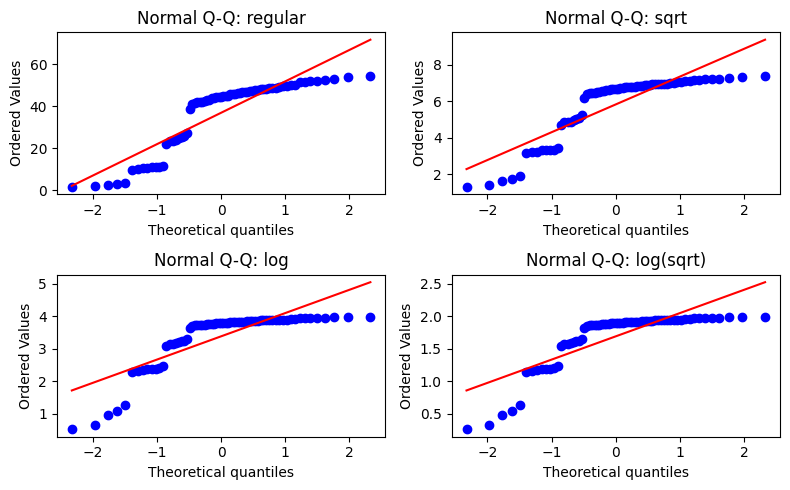

Kruskal-Wallis rank sum test
Data: avg_daily_intakes by moonphase
  Chi-squared = 0.95068, p-value = 9.95585e-01


In [4]:
intake_per_moon_output = intake_per_moon(apt_per_phase)

In [5]:
def plot_moon_phases(df, y_axis, title_text):
    
    phase_order = [
        'new_moon', 'waxing_crescent', 'first_quarter', 'waxing_gibbous', 
        'full', 'waning_gibbous', 'third_quarter', 'waning_crescent'
    ]
    
    
    df_clean = df.copy()
    moon_category = CategoricalDtype(categories=phase_order, ordered=True)
    df_clean['moonphase'] = df_clean['moonphase'].astype(moon_category)
    
    
    p = (
        pm.ggplot(df_clean, pm.aes(x = 'moonphase', y = y_axis)) 
        + pm.geom_col(fill='lightblue') 
        + pm.theme_minimal() 
        + pm.theme(axis_text_x = pm.element_text(angle=45, hjust=1)) 
        + pm.labs(
            title=title_text, 
            subtitle = 'Veterinary Nurse Analysis of Shelter Data Over 6 years'
        )
    )
    return p




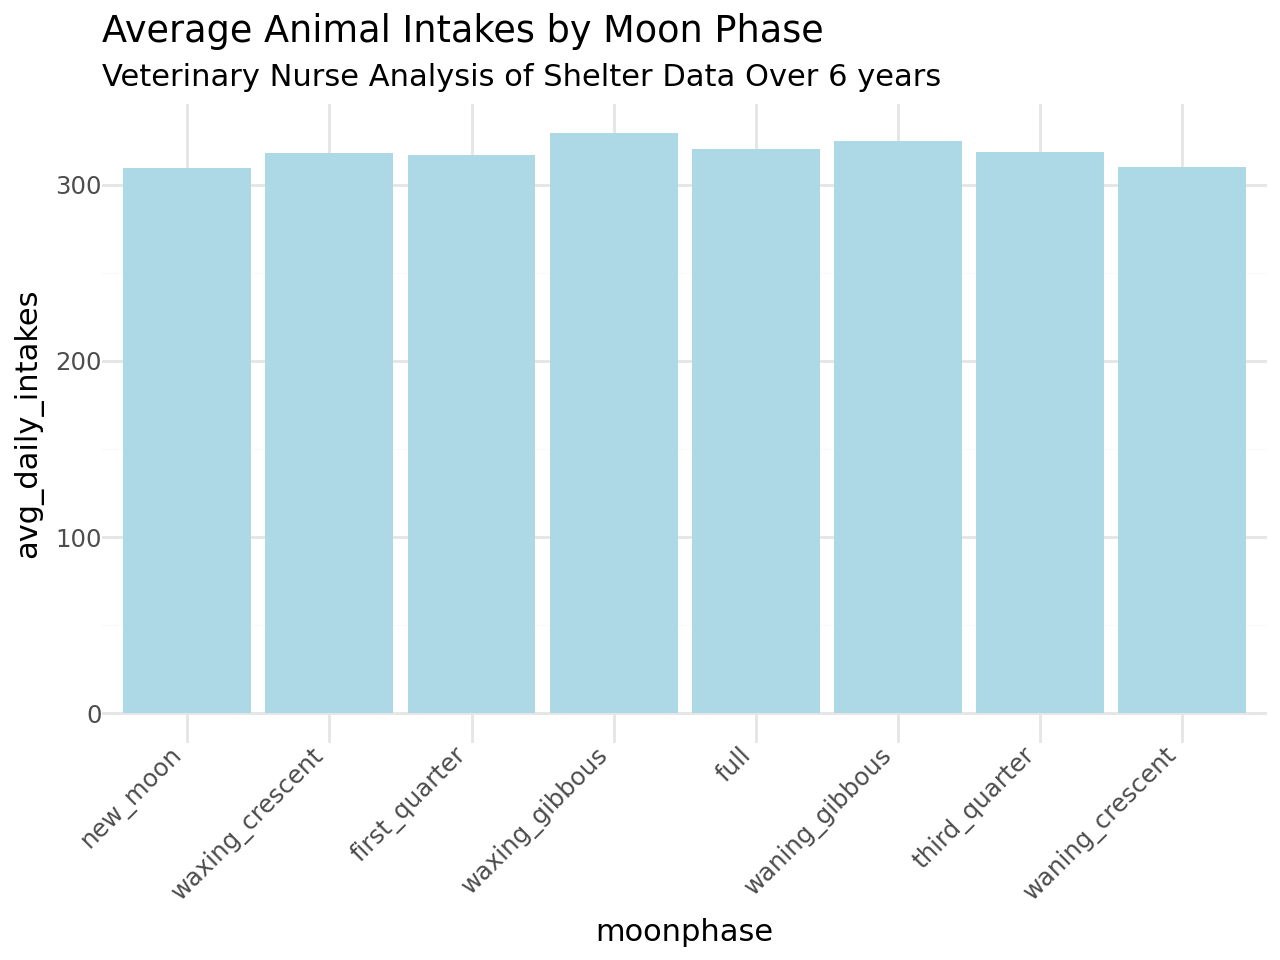

In [6]:
plot_moon_phases(intake_per_moon_output, 'avg_daily_intakes', 'Average Animal Intakes by Moon Phase')

avg_p_deceased by moonphase


Regular (avg_p_deceased)
Transformation: Regular (avg_p_deceased)
  W = 0.93256, p-value = 1.07920e-03

Log (log(avg_p_deceased + 0.001))
Transformation: Log (log(avg_p_deceased + 0.001))
  W = 0.85101, p-value = 8.35600e-07

Sqrt (sqrt(avg_p_deceased))
Transformation: Sqrt (sqrt(avg_p_deceased))
  W = 0.96178, p-value = 3.33768e-02

Log-Sqrt (log(sqrt(avg_p_deceased) + 0.001))
Transformation: Log-Sqrt (log(sqrt(avg_p_deceased) + 0.001))
  W = 0.85035, p-value = 7.96477e-07



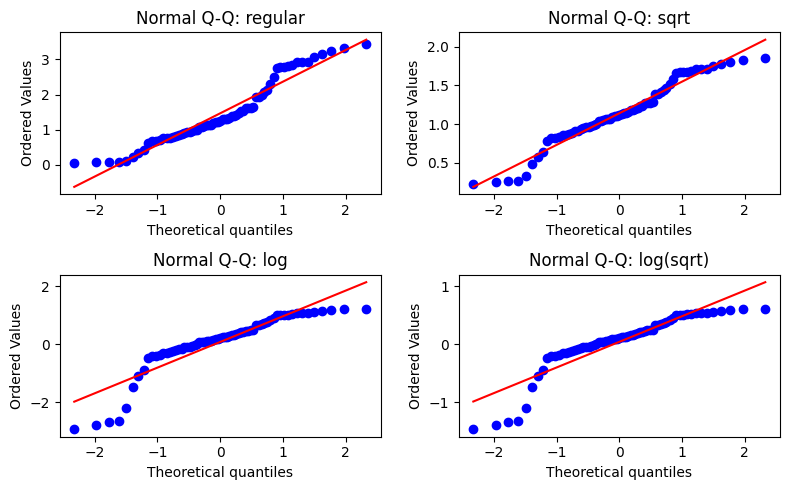

Kruskal-Wallis rank sum test
Data: avg_p_deceased by moonphase
  Chi-squared = 0.68243, p-value = 9.98467e-01


In [7]:
deceased_per_moon_output = deceased_per_moon(apt_per_phase)

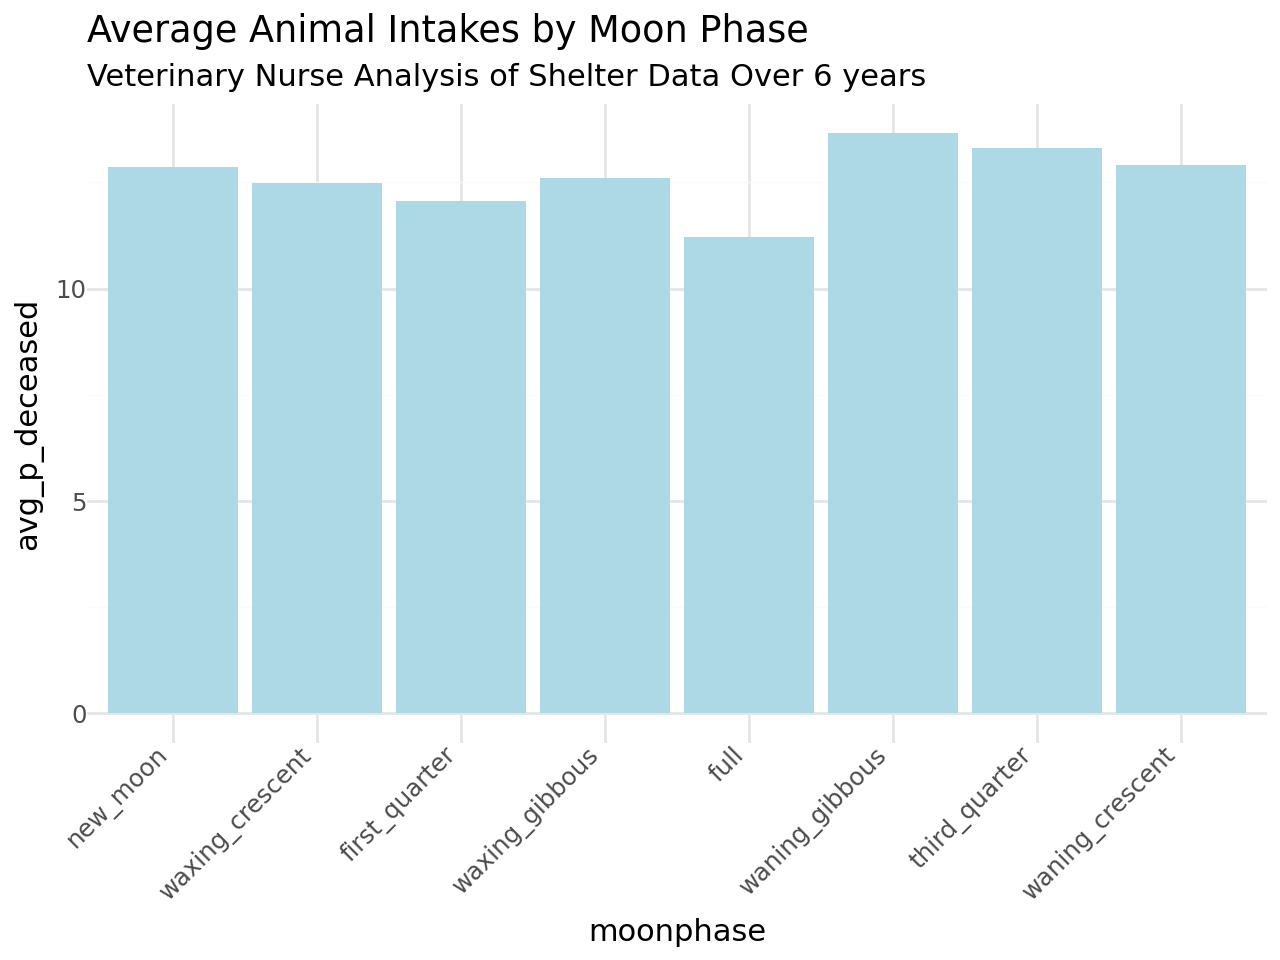

In [8]:
plot_moon_phases(intake_per_moon_output, 'avg_p_deceased', 'Average Animal Intakes by Moon Phase')

In [9]:
vars_to_plot = ['temp(\u00b0F)', 'feels_like(°F)', 'humidity(%)', 'precip(in)', 'wind_gust(mph)','wind_speed(mph)', 
                'sea_level_pressure(mb)','visibility(mi)', 'solar_radiation(W/m\u00b2)', 'solar_energy(MJ/m\u00b2)']

long_data = weather_y_apts_per_day.melt(id_vars=['apt_seen', 'p_deceased'], value_vars=vars_to_plot)


In [10]:
def plot_environmental_factors(df, y_axis, y_label_text, title_text):
    p = (
        pm.ggplot(df, pm.aes(x='value', y=y_axis)) 
        + pm.geom_point(alpha=0.5, color='steelblue') 
        + pm.geom_smooth(method='lm', color='firebrick', se=True) 
        + pm.facet_wrap('~variable', scales='free_x', ncol=2) 
        + pm.labs(
            title = title_text, 
            x = 'Metric Value', 
            y = y_label_text
        ) 
        + pm.theme_minimal()
    )
    return p

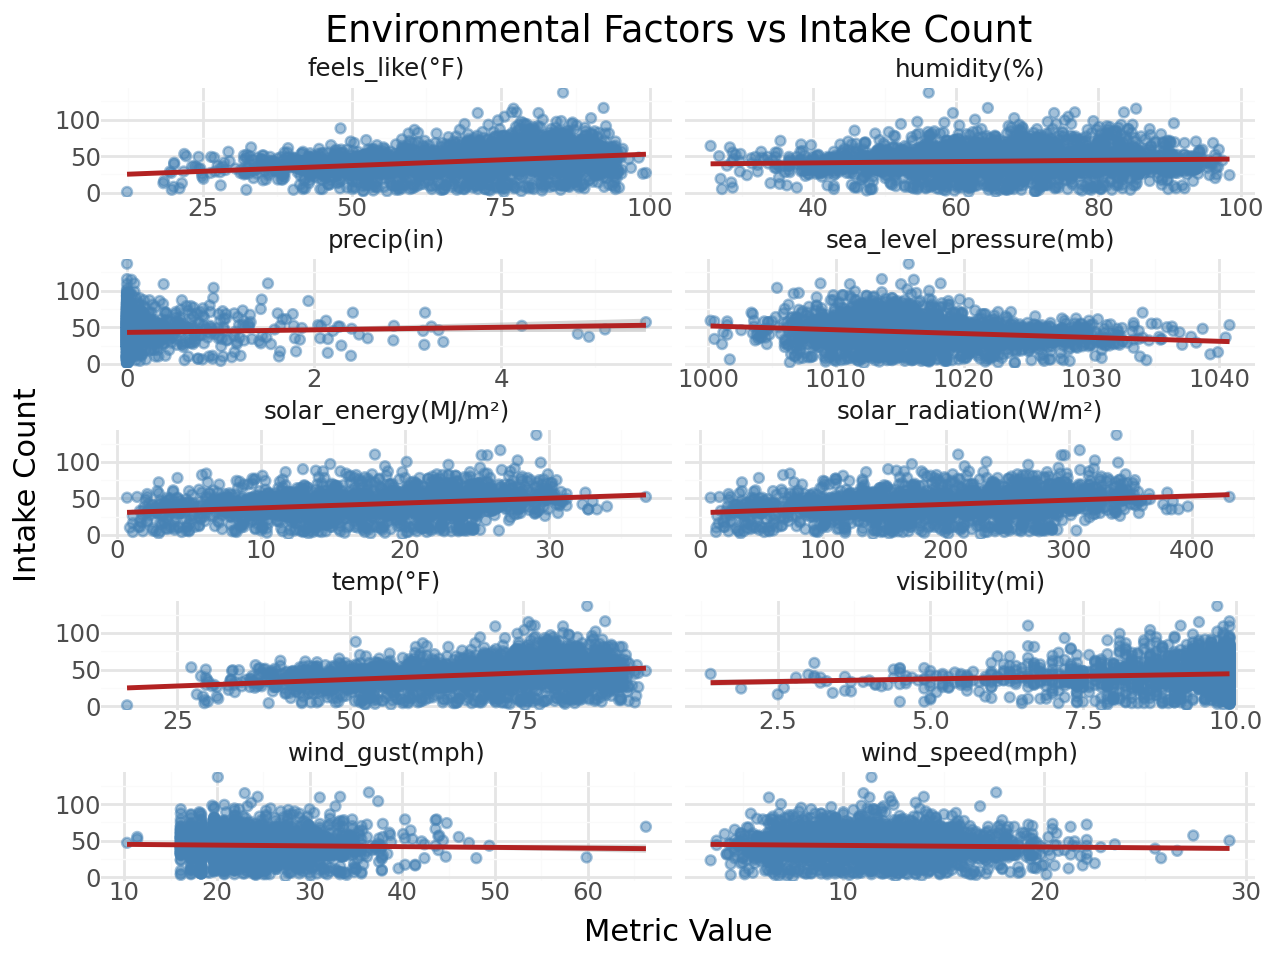

In [11]:
plot_environmental_factors(
    long_data, 
    y_axis = 'apt_seen', 
    y_label_text = 'Intake Count', 
    title_text = 'Environmental Factors vs Intake Count'
)





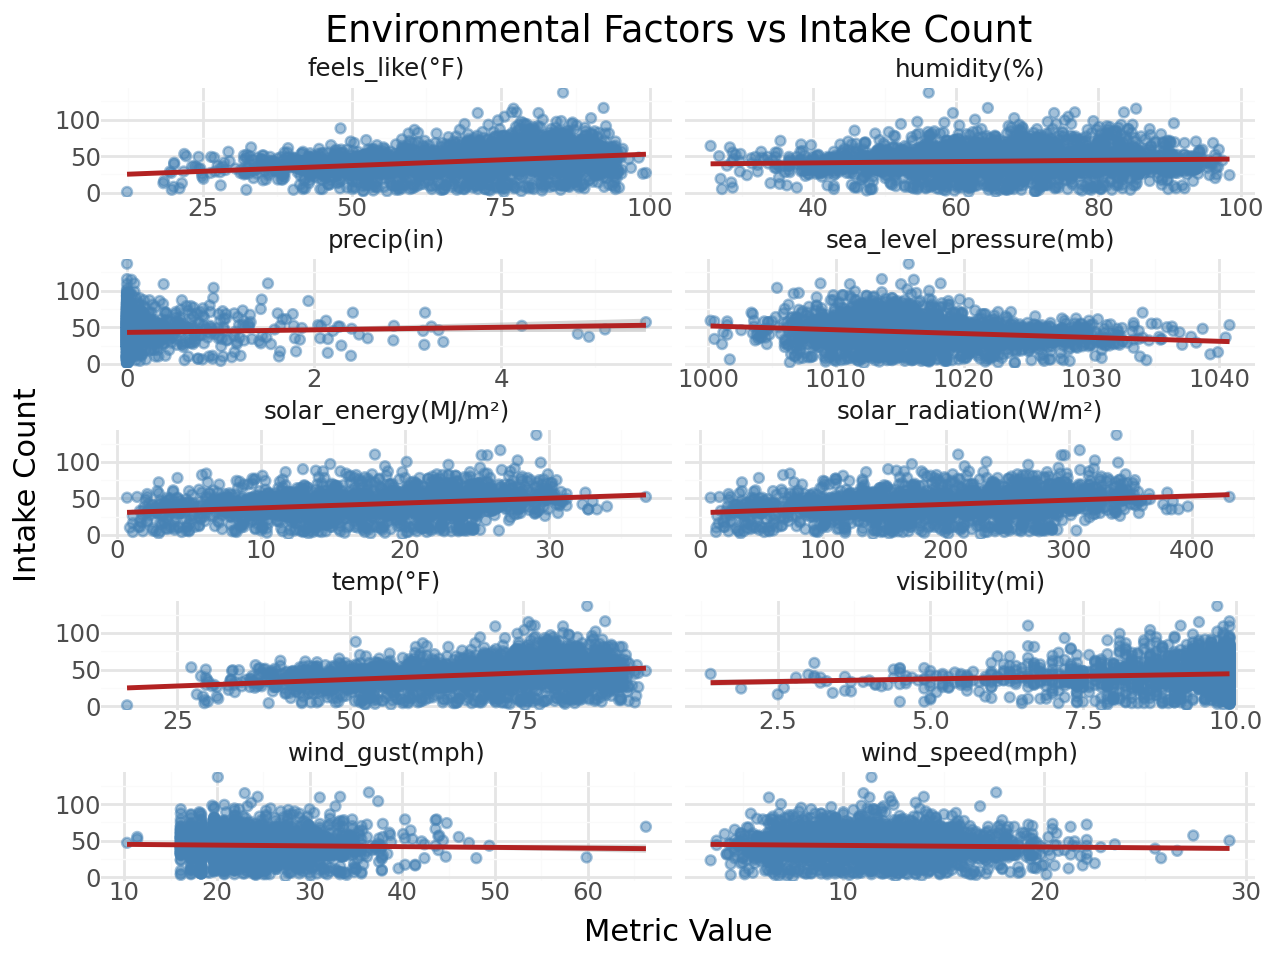

In [12]:
plot_environmental_factors(
    long_data,
    y_axis="apt_seen",
    y_label_text="Intake Count",
    title_text="Environmental Factors vs Intake Count",
)

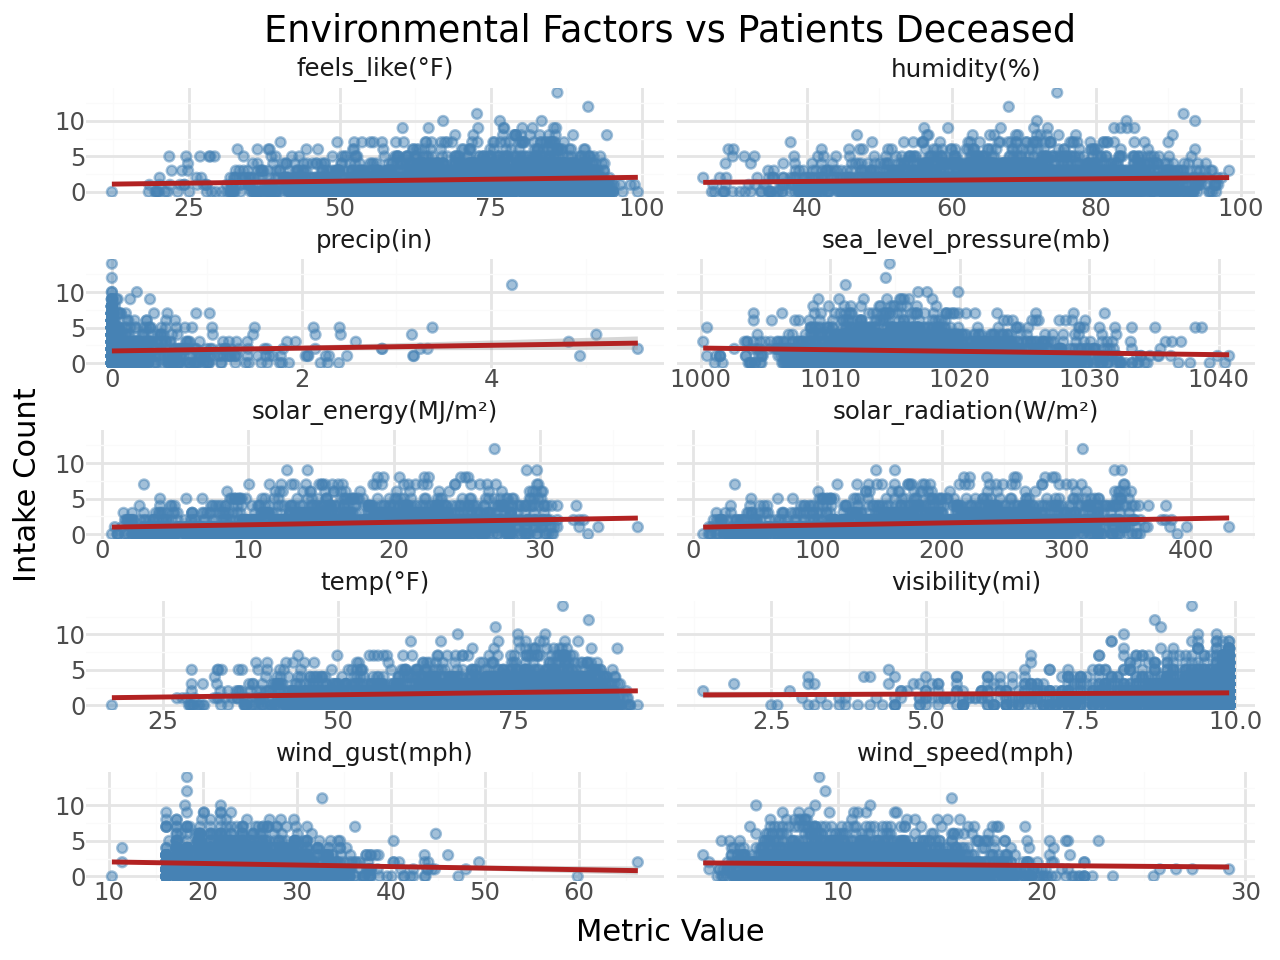

In [13]:
plot_environmental_factors(
    long_data, 
    y_axis='p_deceased', 
    y_label_text='Intake Count', 
    title_text='Environmental Factors vs Patients Deceased'
)

In [14]:
def scatter_slopes(df):
    df_clean = df.dropna(subset=['value', 'apt_seen', 'p_deceased'])

    slopes = (df_clean.groupby('variable', observed=False)
              .apply(lambda g: pd.Series({
                  'apt_slope': stats.linregress(g['value'], g['apt_seen']).slope,
                  'apt_p_value': stats.linregress(g['value'], g['apt_seen']).pvalue,
                  'deceased_slope': stats.linregress(g['value'], g['p_deceased']).slope,
                  'deceased_p_value': stats.linregress(g['value'], g['p_deceased']).pvalue
              }), include_groups=False)
              .reset_index())

    slopes = slopes.reindex(slopes['apt_slope'].abs().sort_values(ascending = False).index)
    return(slopes)


In [15]:
p = scatter_slopes(long_data)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
print(p)

                 variable  apt_slope   apt_p_value  deceased_slope  deceased_p_value
2              precip(in)   1.756304  3.743576e-02        0.198767      2.366402e-02
7          visibility(mi)   1.430023  4.382915e-07        0.033565      2.557773e-01
4     solar_energy(MJ/m²)   0.663202  3.151619e-33        0.035361      5.871153e-11
3  sea_level_pressure(mb)  -0.526960  7.459189e-22       -0.023225      5.366816e-05
6                temp(°F)   0.359337  1.556678e-56        0.012824      1.027302e-07
0          feels_like(°F)   0.314715  1.275256e-55        0.010983      2.445127e-07
9         wind_speed(mph)  -0.214603  2.498588e-02       -0.022498      2.398064e-02
8          wind_gust(mph)  -0.104329  1.262518e-01       -0.021856      2.086259e-03
1             humidity(%)   0.088858  2.949824e-04        0.009265      2.882542e-04
5   solar_radiation(W/m²)   0.057415  2.164779e-33        0.003056      5.638321e-11


In [16]:
comparison_results = []

for variable in long_data['variable'].unique():
    sub_df = long_data[long_data['variable'] == variable]
    
    # Run linear regression for appointments
    reg_apt = stats.linregress(sub_df['value'], sub_df['apt_seen'])
    m1, se1 = reg_apt.slope, reg_apt.stderr
    
    # Run linear regression for deceased patients
    reg_dec = stats.linregress(sub_df['value'], sub_df['p_deceased'])
    m2, se2 = reg_dec.slope, reg_dec.stderr
    
    # Calculate the Z-statistic and p-value for the difference between the slopes
    # Formula: Z = (Slope1 - Slope2) / Sqrt(SE1^2 + SE2^2)
    z_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat))) # Two-tailed test
    
    comparison_results.append({
        'variable': variable,
        'apt_slope': m1,
        'deceased_slope': m2,
        'z_statistic': z_stat,
        'p_value_of_difference': p_value
    })

# Convert to DataFrame and print
slope_comparison_df = pd.DataFrame(comparison_results)
pd.set_option('display.width', 1000)
print(slope_comparison_df)


                 variable  apt_slope  deceased_slope  z_statistic  p_value_of_difference
0                temp(°F)   0.359337        0.012824    15.549721           0.000000e+00
1          feels_like(°F)   0.314715        0.010983    15.426028           0.000000e+00
2             humidity(%)   0.088858        0.009265     3.229022           1.242142e-03
3              precip(in)   1.756304        0.198767     1.836456           6.629024e-02
4          wind_gust(mph)        NaN             NaN          NaN                    NaN
5         wind_speed(mph)  -0.214603       -0.022498    -1.996951           4.583050e-02
6  sea_level_pressure(mb)  -0.526960       -0.023225    -9.212267           0.000000e+00
7          visibility(mi)   1.430023        0.033565     4.918256           8.731850e-07
8   solar_radiation(W/m²)        NaN             NaN          NaN                    NaN
9     solar_energy(MJ/m²)        NaN             NaN          NaN                    NaN


In [17]:
def format_p_value(val):
    if val < 0.00001:
        return f'{val:.5e}' 
    else:
        return f'{val:.5f}' 

def run_pairwise_wilcoxon(df, x_axis, y_axis, bins, labels, title_text):
    
    df_clean = df.dropna(subset=[x_axis, y_axis]).copy()
    scale_col = f'{x_axis}_scale'
    df_clean[scale_col] = pd.cut(df_clean[x_axis], bins = bins, labels = labels, ordered = True)
    
    
    groups = { 
        str(name): group[y_axis].to_numpy() 
        for name, group in df_clean.groupby(scale_col, observed = False)
    }
    
    
    # n * (n - 1)) / 2
    num_categories = len(labels)
    total_comparisons = int((num_categories * (num_categories - 1)) / 2)
    
    
    pairwise_results = []
    for i in range(num_categories):
        for j in range(i + 1, num_categories):
            g1, g2 = labels[i], labels[j]
            
            if g1 in groups and g2 in groups and len(groups[g1]) > 0 and len(groups[g2]) > 0:
                _, p_val = stats.mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
                
                
                p_adjusted = min(p_val * total_comparisons, 1.0)
                pairwise_results.append({'Comparison': f'{g1} vs {g2}', 'p-value (adj)': p_adjusted})
                
    
    results_df = pd.DataFrame(pairwise_results)
    
    results_df['p-value (adj)'] = results_df['p-value (adj)'].apply(format_p_value)
    
    
    print(f'--- Pairwise Wilcoxon Rank Sum Test ({title_text}) ---')
    print(f'{'Comparison':<45} | {'p-value (Adjusted)':<20}')
    print('-' * 70)
    
    for _, row in results_df.iterrows():
        print(f'{row['Comparison']:<45} | {row['p-value (adj)']:<20}')
    print('-' * 70)

In [18]:
from IPython.display import display

weather_variable_configs = [
    {
        'x_axis': 'precip(in)', 'x_label': 'Precipitation (in)', 'bin_size': 1,
        'bins': [-0.001, 0, 0.1, 0.5, np.inf],
        'labels': ['None (0 in)', 'Light (0.01-0.10 in)', 'Moderate (0.11-0.50 in)', 'Heavy (>0.50 in)'],
        'name': 'Rainfall Intensity', 'x_scale_label': 'Rain Scale',
    },
    {
        'x_axis': 'visibility(mi)', 'x_label': 'Visibility (mi)', 'bin_size': 1,
        'bins': [-0.001, 1, 4, 9, np.inf],
        'labels': ['Dense Fog (<1mi)', 'Haze/Mist (1-4mi)', 'Moderate (4-9mi)', 'Clear Sky (>9mi)'],
        'name': 'Atmospheric Visibility', 'x_scale_label': 'Visibility Scale',
    },
    {
        'x_axis': 'feels_like(°F)', 'x_label': 'Feels Like (°F)', 'bin_size': 2,
        'bins': [-np.inf, 20, 40, 60, 80, 100, np.inf],
        'labels': ['< 20°F', '20 - 40°F', '40 - 60°F', '60 - 80°F', '80 - 100°F', '> 100°F'],
        'name': 'Feels Like Temperature', 'x_scale_label': 'Temperature Scale (°F)',
    },
    {
        'x_axis': 'sea_level_pressure(mb)', 'x_label': 'sea_level_pressure(mb)', 'bin_size': 2,
        'bins': [-np.inf, 1000, 1020, 1030, 1040, np.inf],
        'labels': ['< 1000', '1000 - 1020', '1020 - 1030', '1030 - 1040', '> 1040'],
        'name': 'Barometric Pressure', 'x_scale_label': 'Barometric Pressure Scale (mb)',
    },
    {
        'x_axis': 'wind_speed(mph)', 'x_label': 'wind_speed(mph)', 'bin_size': 2,
        'bins': [-0.001, 5, 10, 15, 20, 25, np.inf],
        'labels': ['Calm (<5mph)', 'Light (5-10mph)', 'Moderate (10-15mph)', 'Breezy (15-20mph)', 'Blustery (20-25mph)', 'Storm (>25mph)'],
        'name': 'Wind Speed Dynamics', 'x_scale_label': 'Wind Speed Scale',
    },
    {
        'x_axis': 'humidity(%)', 'x_label': 'Relative Humidity (%)', 'bin_size': 5,
        'bins': [-0.001, 40, 60, 80, np.inf],
        'labels': ['Dry (<40%)', 'Comfortable (40-60%)', 'Humid (60-80%)', 'Oppressive (>80%)'],
        'name': 'Relative Humidity Zones', 'x_scale_label': 'Humidity Scale',
    },
]

In [19]:
def build_binned_long_df(df, y_axis, configs):
    frames = []
    for cfg in configs:
        sub = df.dropna(subset=[cfg['x_axis'], y_axis]).copy()
        sub['bin_label'] = pd.Categorical(
            pd.cut(sub[cfg['x_axis']], bins=cfg['bins'], labels=cfg['labels'], ordered=True),
            categories=cfg['labels'], ordered=True
        )
        sub['variable'] = cfg['name']
        sub['y_value'] = sub[y_axis]
        frames.append(sub[['variable', 'bin_label', 'y_value']])
    return pd.concat(frames, ignore_index=True)

def plot_all_boxplots(df, y_axis, y_label, outcome_name, configs):
    long_binned = build_binned_long_df(df, y_axis, configs)
    p = (
        pm.ggplot(long_binned, pm.aes(x='bin_label', y='y_value', fill='bin_label'))
        + pm.geom_boxplot(color='#333333', size=0.6, fatten=1.5, outlier_size=0.5)
        + pm.facet_wrap('~variable', scales='free', ncol=2)
        + pm.scale_fill_brewer(type='qual', palette='Set2')
        + pm.theme_minimal()
        + pm.theme(axis_text_x=pm.element_text(rotation=45, hjust=1), legend_position='none')
        + pm.labs(title=f'Shelter {outcome_name} by Weather Condition', x='', y=y_label)
    )
    return p

In [20]:
p = plot_all_boxplots(weather_y_apts_per_day, y_axis='p_deceased', y_label='Deceased Count', outcome_name='Mortality', configs=weather_variable_configs)
p.save('weather_v_mortality_boxplots.png', width=10, height=8, dpi=300, facecolor='white', transparent=False)

In [21]:
from PIL import Image

# Save as before (transparency will still be there, that's fine -- we fix it next)
p.save('weather_v_mortality_boxplots.png', width=10, height=8, dpi=300)

# Flatten onto a solid white background
img = Image.open('weather_v_mortality_boxplots.png').convert('RGBA')
background = Image.new('RGBA', img.size, (255, 255, 255, 255))
flattened = Image.alpha_composite(background, img).convert('RGB')
flattened.save('weather_v_mortality_boxplots.png')

# Verify
check = Image.open('weather_v_mortality_boxplots.png')
print(check.mode)

RGB


In [22]:
def run_all_wilcoxon(df, y_axis, outcome_name, configs):
    for cfg in configs:
        run_pairwise_wilcoxon(
            df=df, x_axis=cfg['x_axis'], y_axis=y_axis,
            bins=cfg['bins'], labels=cfg['labels'],
            title_text=f"{cfg['name']} ({outcome_name})"
        )
        print()

run_all_wilcoxon(weather_y_apts_per_day, y_axis='apt_seen', outcome_name='Intake', configs=weather_variable_configs)
run_all_wilcoxon(weather_y_apts_per_day, y_axis='p_deceased', outcome_name='Mortality', configs=weather_variable_configs)

--- Pairwise Wilcoxon Rank Sum Test (Rainfall Intensity (Intake)) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
None (0 in) vs Light (0.01-0.10 in)           | 1.00000             
None (0 in) vs Moderate (0.11-0.50 in)        | 0.27418             
None (0 in) vs Heavy (>0.50 in)               | 0.03755             
Light (0.01-0.10 in) vs Moderate (0.11-0.50 in) | 0.35460             
Light (0.01-0.10 in) vs Heavy (>0.50 in)      | 0.06142             
Moderate (0.11-0.50 in) vs Heavy (>0.50 in)   | 1.00000             
----------------------------------------------------------------------

--- Pairwise Wilcoxon Rank Sum Test (Atmospheric Visibility (Intake)) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
Haze/Mist (1-4mi) vs Moderate (4-9mi)         | 0.12649             
Haze/Mist (1-4mi) v

In [24]:
weather_y_apts_per_day['pressure_z'] = (weather_y_apts_per_day['sea_level_pressure(mb)'] - weather_y_apts_per_day['sea_level_pressure(mb)'].mean()) / weather_y_apts_per_day['sea_level_pressure(mb)'].std()
weather_y_apts_per_day['feels_like_z'] = (weather_y_apts_per_day['feels_like(°F)'] - weather_y_apts_per_day['feels_like(°F)'].mean()) / weather_y_apts_per_day['feels_like(°F)'].std()

import statsmodels.api as sm

for outcome, label in [('apt_seen', 'Intake'), ('p_deceased', 'Mortality')]:
    model_df = weather_y_apts_per_day.dropna(subset=['pressure_z', 'feels_like_z', outcome])
    X = sm.add_constant(model_df[['pressure_z', 'feels_like_z']])
    y = model_df[outcome]
    result = sm.NegativeBinomial(y, X).fit(method='bfgs', maxiter=200, disp=0)
    print(f'=== {label}: Pressure + Temperature (multivariate) ===')
    print(result.summary())
    print()

=== Intake: Pressure + Temperature (multivariate) ===
                     NegativeBinomial Regression Results                      
Dep. Variable:               apt_seen   No. Observations:                 2708
Model:               NegativeBinomial   Df Residuals:                     2705
Method:                           MLE   Df Model:                            2
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                0.009297
Time:                        20:38:32   Log-Likelihood:                -11564.
converged:                       True   LL-Null:                       -11673.
Covariance Type:            nonrobust   LLR p-value:                 7.358e-48
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.7576      0.008    465.922      0.000       3.742       3.773
pressure_z       0.0110      0.011      1.013      0.311      -0.010   

In [25]:
p_intake = plot_all_boxplots(weather_y_apts_per_day, y_axis='apt_seen', y_label='Average Appointments', outcome_name='Intake', configs=weather_variable_configs)
p_intake.save('weather_v_intake_boxplots.png', width=10, height=8, dpi=300)

img = Image.open('weather_v_intake_boxplots.png').convert('RGBA')
background = Image.new('RGBA', img.size, (255, 255, 255, 255))
flattened = Image.alpha_composite(background, img).convert('RGB')
flattened.save('weather_v_intake_boxplots.png')

check = Image.open('weather_v_intake_boxplots.png')
print(check.mode)

RGB


In [26]:
def get_min_adjusted_pvalue(df, x_axis, y_axis, bins, labels):
    df_clean = df.dropna(subset=[x_axis, y_axis]).copy()
    scale_col = f'{x_axis}_scale'
    df_clean[scale_col] = pd.cut(df_clean[x_axis], bins=bins, labels=labels, ordered=True)
    groups = {str(name): group[y_axis].to_numpy() for name, group in df_clean.groupby(scale_col, observed=False)}
    num_categories = len(labels)
    total_comparisons = int((num_categories * (num_categories - 1)) / 2)
    p_values = []
    for i in range(num_categories):
        for j in range(i + 1, num_categories):
            g1, g2 = labels[i], labels[j]
            if g1 in groups and g2 in groups and len(groups[g1]) > 0 and len(groups[g2]) > 0:
                _, p_val = stats.mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
                p_values.append(min(p_val * total_comparisons, 1.0))
    return min(p_values) if p_values else np.nan

def summarize_min_pvalues(df, y_axis, outcome_name, configs):
    rows = []
    for cfg in configs:
        min_p = get_min_adjusted_pvalue(df, cfg['x_axis'], y_axis, cfg['bins'], cfg['labels'])
        rows.append({'variable': cfg['name'], 'outcome': outcome_name, 'min_p_adjusted': min_p})
    return pd.DataFrame(rows)

intake_summary = summarize_min_pvalues(weather_y_apts_per_day, 'apt_seen', 'Intake', weather_variable_configs)
mortality_summary = summarize_min_pvalues(weather_y_apts_per_day, 'p_deceased', 'Mortality', weather_variable_configs)
combined_summary = pd.concat([intake_summary, mortality_summary], ignore_index=True)
combined_summary['neg_log10_p'] = -np.log10(combined_summary['min_p_adjusted'].clip(lower=1e-300))
print(combined_summary)

p = (
    pm.ggplot(combined_summary, pm.aes(x='variable', y='neg_log10_p', fill='outcome'))
    + pm.geom_col(position='dodge', color='#333333')
    + pm.geom_hline(yintercept=-np.log10(0.05), linetype='dashed', color='red')
    + pm.coord_flip()
    + pm.theme_minimal()
    + pm.theme(
        plot_background=pm.element_rect(fill='white', color='white'),
        panel_background=pm.element_rect(fill='white', color='white'),
        legend_position='top'
    )
    + pm.labs(
        title='Statistical Significance: Weather Effects on Intake vs. Mortality',
        x='', y='-log10(minimum adjusted p-value)', fill='Outcome'
    )
)
p.save('weather_significance_summary.png', width=10, height=6, dpi=300)

img = Image.open('weather_significance_summary.png').convert('RGBA')
background = Image.new('RGBA', img.size, (255, 255, 255, 255))
Image.alpha_composite(background, img).convert('RGB').save('weather_significance_summary.png')
print(Image.open('weather_significance_summary.png').mode)

                   variable    outcome  min_p_adjusted  neg_log10_p
0        Rainfall Intensity     Intake    3.755165e-02     1.425371
1    Atmospheric Visibility     Intake    1.162281e-02     1.934689
2    Feels Like Temperature     Intake    1.702928e-45    44.768804
3       Barometric Pressure     Intake    2.586034e-23    22.587366
4       Wind Speed Dynamics     Intake    1.122559e-01     0.949791
5   Relative Humidity Zones     Intake    2.160518e-03     2.665442
6        Rainfall Intensity  Mortality    4.622050e-01     0.335165
7    Atmospheric Visibility  Mortality    1.000000e+00    -0.000000
8    Feels Like Temperature  Mortality    4.158236e-09     8.381091
9       Barometric Pressure  Mortality    7.788073e-06     5.108570
10      Wind Speed Dynamics  Mortality    1.000000e+00    -0.000000
11  Relative Humidity Zones  Mortality    6.528603e-03     2.185180
RGB


In [27]:
!pip freeze > requirements.txt